# Importing Necessary Libraries and Data:

In [1]:
import tensorflow as tf

print(tf.__version__)

2.15.0


In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import mae, mse
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import r2_score

In [5]:
df = pd.read_csv("/content/kc_house_data.csv")

In [6]:
df.head(10)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,10/13/2014,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,12/9/2014,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,2/25/2015,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,12/9/2014,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,2/18/2015,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
5,7237550310,5/12/2014,1230000.0,4,4.50,5420,101930,1.0,0,0,...,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
6,1321400060,6/27/2014,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
7,2008000270,1/15/2015,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711
8,2414600126,4/15/2015,229500.0,3,1.00,1780,7470,1.0,0,0,...,7,1050,730,1960,0,98146,47.5123,-122.337,1780,8113
9,3793500160,3/12/2015,323000.0,3,2.50,1890,6560,2.0,0,0,...,7,1890,0,2003,0,98038,47.3684,-122.031,2390,7570


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21597 non-null  int64  
 1   date           21597 non-null  object 
 2   price          21597 non-null  float64
 3   bedrooms       21597 non-null  int64  
 4   bathrooms      21597 non-null  float64
 5   sqft_living    21597 non-null  int64  
 6   sqft_lot       21597 non-null  int64  
 7   floors         21597 non-null  float64
 8   waterfront     21597 non-null  int64  
 9   view           21597 non-null  int64  
 10  condition      21597 non-null  int64  
 11  grade          21597 non-null  int64  
 12  sqft_above     21597 non-null  int64  
 13  sqft_basement  21597 non-null  int64  
 14  yr_built       21597 non-null  int64  
 15  yr_renovated   21597 non-null  int64  
 16  zipcode        21597 non-null  int64  
 17  lat            21597 non-null  float64
 18  long  

In [8]:
df.isna().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

# EDA:

<Figure size 600x600 with 0 Axes>

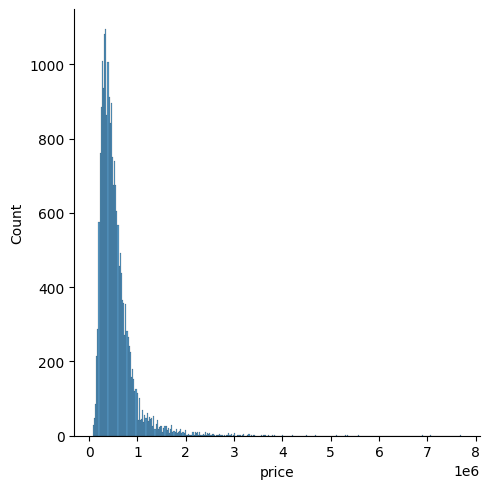

In [9]:
plt.figure(figsize= (6,6))
sns.displot(x= df["price"])
plt.show()

In [10]:
len(df[df["price"] > 2000000])

198

In [11]:
len(df)

21597

In [12]:
# As only 198 Houses out of total 21597 Jouses have Prices Greater Than 2M, we can Treat those 198 Houses as outliers.
# We will Train Model on all Houses and also only on Houses with Prices less than 2M and Compare Accuracies.

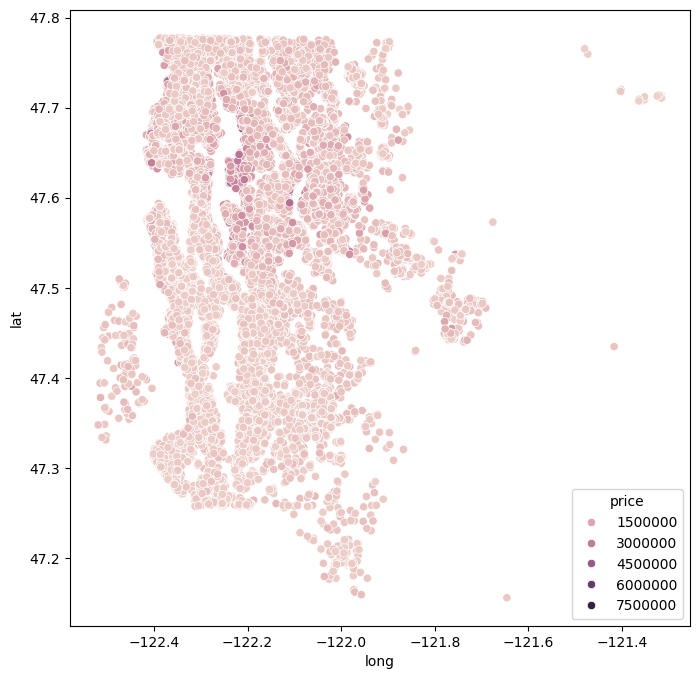

In [13]:
# Price of Houses According to Location:
plt.figure(figsize= (8,8))
sns.scatterplot(data= df, x= "long", y= "lat", hue= "price")
plt.show()

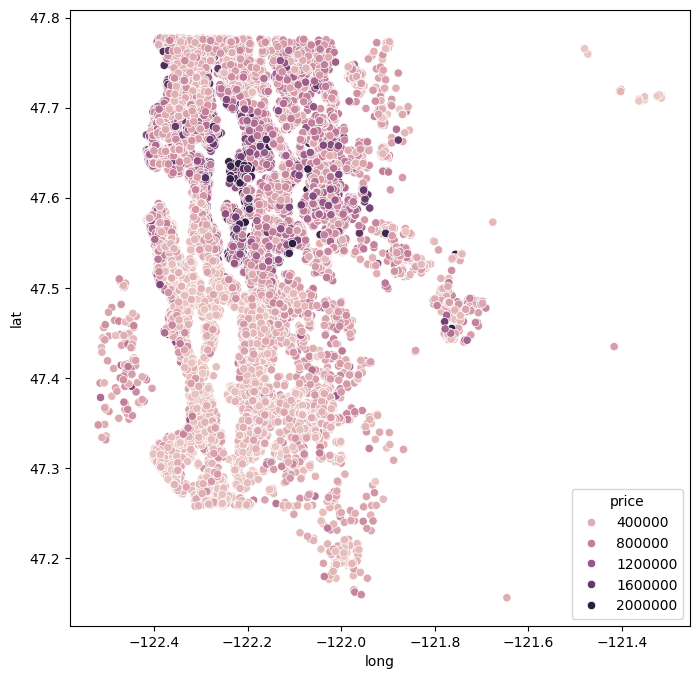

In [14]:
# Price of Houses According to Location (Houses Under Price of 2M):
plt.figure(figsize= (8,8))
sns.scatterplot(data= df[df['price'] <= 2000000], x= "long", y= "lat", hue= "price")
plt.show()

In [15]:
df["waterfront"].value_counts()

waterfront
0    21434
1      163
Name: count, dtype: int64

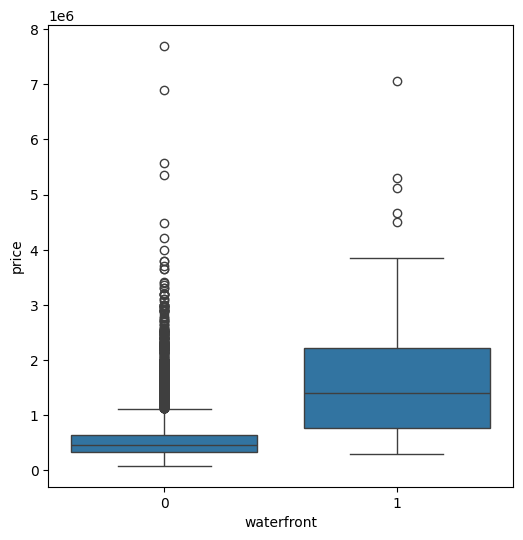

In [16]:
# Distribution of House Prices According to Waterfront:
plt.figure(figsize= (6,6))
sns.boxplot(data= df, x= "waterfront", y= "price")
plt.show()

# Feature Engineering:

In [17]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21597 non-null  int64  
 1   date           21597 non-null  object 
 2   price          21597 non-null  float64
 3   bedrooms       21597 non-null  int64  
 4   bathrooms      21597 non-null  float64
 5   sqft_living    21597 non-null  int64  
 6   sqft_lot       21597 non-null  int64  
 7   floors         21597 non-null  float64
 8   waterfront     21597 non-null  int64  
 9   view           21597 non-null  int64  
 10  condition      21597 non-null  int64  
 11  grade          21597 non-null  int64  
 12  sqft_above     21597 non-null  int64  
 13  sqft_basement  21597 non-null  int64  
 14  yr_built       21597 non-null  int64  
 15  yr_renovated   21597 non-null  int64  
 16  zipcode        21597 non-null  int64  
 17  lat            21597 non-null  float64
 18  long  

In [19]:
# Changing Date Column to Data Datatype:
df["date"] = pd.to_datetime(df["date"])

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             21597 non-null  int64         
 1   date           21597 non-null  datetime64[ns]
 2   price          21597 non-null  float64       
 3   bedrooms       21597 non-null  int64         
 4   bathrooms      21597 non-null  float64       
 5   sqft_living    21597 non-null  int64         
 6   sqft_lot       21597 non-null  int64         
 7   floors         21597 non-null  float64       
 8   waterfront     21597 non-null  int64         
 9   view           21597 non-null  int64         
 10  condition      21597 non-null  int64         
 11  grade          21597 non-null  int64         
 12  sqft_above     21597 non-null  int64         
 13  sqft_basement  21597 non-null  int64         
 14  yr_built       21597 non-null  int64         
 15  yr_renovated   2159

In [21]:
## Creating Month and Year Features from Date:

df["month"] = df["date"].apply(lambda date: date.month)
df["year"] = df["date"].apply(lambda date: date.year)

In [22]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,month,year
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,...,0,1955,0,98178,47.5112,-122.257,1340,5650,10,2014
1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,...,400,1951,1991,98125,47.7210,-122.319,1690,7639,12,2014
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,...,0,1933,0,98028,47.7379,-122.233,2720,8062,2,2015
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,...,910,1965,0,98136,47.5208,-122.393,1360,5000,12,2014
4,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,0,...,0,1987,0,98074,47.6168,-122.045,1800,7503,2,2015


In [23]:
# Dropping "id", "date" and "zipcode":
df = df.drop(["id","date", "zipcode"], axis= 1)

In [24]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15,month,year
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,47.5112,-122.257,1340,5650,10,2014
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,47.7210,-122.319,1690,7639,12,2014
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,47.7379,-122.233,2720,8062,2,2015
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,47.5208,-122.393,1360,5000,12,2014
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,47.6168,-122.045,1800,7503,2,2015


# Creating Model 1 on Full Data:

## Train Test Split and Scalling:

In [25]:
# Features and Target:
x = df.drop("price", axis= 1)
y = df["price"]

In [26]:
# Train Test Split:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.25, random_state= 42)

In [27]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((16197, 19), (5400, 19), (16197,), (5400,))

In [28]:
# Scalling The Data:
sc1 = StandardScaler()

x_train = sc1.fit_transform(x_train)
x_test = sc1.transform(x_test)

In [29]:
x_train, x_test

(array([[-4.10884054e-01,  4.99428920e-01, -2.21843992e-01, ...,
         -2.85849263e-01, -1.14863675e+00,  1.44951417e+00],
        [-4.10884054e-01,  4.99428920e-01, -6.93686769e-02, ...,
         -2.84470341e-01,  1.09975395e+00, -6.89886323e-01],
        [ 1.79680844e+00,  2.45248921e+00,  2.87122669e+00, ...,
          7.70548916e+00, -1.79103409e+00,  1.44951417e+00],
        ...,
        [ 6.92962193e-01, -8.02611274e-01, -6.03032280e-01, ...,
         -1.59659251e-01,  1.36157935e-01, -6.89886323e-01],
        [-2.61857655e+00, -1.77914142e+00, -1.85550808e+00, ...,
          8.25838320e-02, -1.85040736e-01, -6.89886323e-01],
        [ 6.92962193e-01,  4.99428920e-01,  7.31126728e-01, ...,
          1.74917865e-03, -1.14863675e+00,  1.44951417e+00]]),
 array([[-0.41088405, -1.77914142, -1.34362667, ..., -0.16405689,
         -1.46983542,  1.44951417],
        [-0.41088405, -1.45363137, -0.62481447, ..., -0.2635629 ,
          1.09975395, -0.68988632],
        [ 0.69296219,  0.

## Creating Data Pipelines:

In [30]:
# Trainig Dataset:
train_features = tf.data.Dataset.from_tensor_slices(x_train)
train_labels = tf.data.Dataset.from_tensor_slices(y_train)
train_dataset = tf.data.Dataset.zip((train_features, train_labels))

train_dataset = train_dataset.batch(128).prefetch(tf.data.AUTOTUNE)

In [31]:
# Test Dataset:
test_features = tf.data.Dataset.from_tensor_slices(x_test)
test_labels = tf.data.Dataset.from_tensor_slices(y_test)
test_dataset = tf.data.Dataset.zip((test_features, test_labels))

test_dataset = test_dataset.batch(128).prefetch(tf.data.AUTOTUNE)

## Creating, Compiling and Fitting The Model:

In [33]:
# Creating The Model:
model1 = Sequential()
model1.add(Dense(32, activation= "relu"))
model1.add(Dense(16, activation= "relu"))
model1.add(Dense(8, activation= "relu"))
model1.add(Dense(1))

# Compiling The Model:
model1.compile(optimizer= Adam(),
               loss= mse,
               metrics= ["mse"])

# Fitting The Model:
model1.fit(train_dataset,
           epochs= 1000,
           validation_data= test_dataset,
           callbacks= [EarlyStopping(monitor= "val_loss",
                                     patience= 5),
                       ModelCheckpoint(filepath= "/content/Model1",
                                       monitor= "val_loss",
                                       save_best_only= True),
                       ReduceLROnPlateau(monitor= "val_loss",
                                         factor= 0.1,
                                         patience= 5,)])

Epoch 1/1000
127/127 [==============================] - 11s 23ms/step - loss: 427169841152.0000 - mse: 427169841152.0000 - val_loss: 425846505472.0000 - val_mse: 425846505472.0000 - lr: 0.0010
Epoch 2/1000
127/127 [==============================] - 2s 19ms/step - loss: 426711023616.0000 - mse: 426711023616.0000 - val_loss: 424654438400.0000 - val_mse: 424654438400.0000 - lr: 0.0010
Epoch 3/1000
127/127 [==============================] - 1s 9ms/step - loss: 423608123392.0000 - mse: 423608123392.0000 - val_loss: 418844508160.0000 - val_mse: 418844508160.0000 - lr: 0.0010
Epoch 4/1000
127/127 [==============================] - 1s 9ms/step - loss: 413037658112.0000 - mse: 413037658112.0000 - val_loss: 402540527616.0000 - val_mse: 402540527616.0000 - lr: 0.0010
Epoch 5/1000
127/127 [==============================] - 1s 11ms/step - loss: 388537057280.0000 - mse: 388537057280.0000 - val_loss: 369404510208.0000 - val_mse: 369404510208.0000 - lr: 0.0010
Epoch 6/1000
127/127 [===================

## Loss Curve of Model:

In [36]:
model1.history.history.keys()

dict_keys(['loss', 'mse', 'val_loss', 'val_mse', 'lr'])

In [35]:
model1.history.history["loss"][:10]

[427169841152.0,
 426711023616.0,
 423608123392.0,
 413037658112.0,
 388537057280.0,
 345408307200.0,
 285063020544.0,
 217599524864.0,
 158562500608.0,
 118737190912.0]

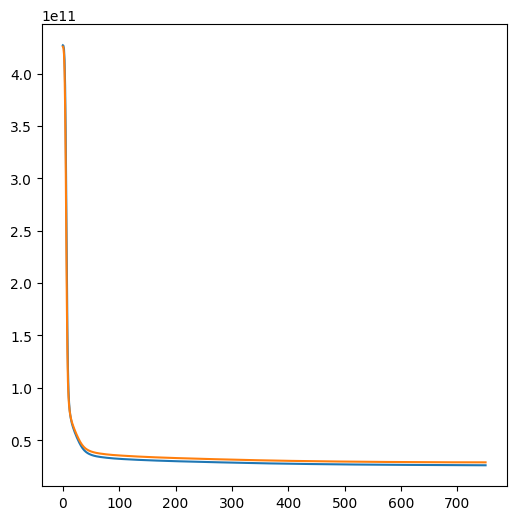

In [38]:
plt.figure(figsize= (6,6))
plt.plot(model1.history.history["loss"])
plt.plot(model1.history.history["val_loss"])
plt.show()

## Model Evaluation:

In [40]:
# Predictions Using Model:
model1_preds = model1.predict(x_test)

169/169 [==============================] - 0s 2ms/step


In [41]:
model1_preds

array([[ 230714.2 ],
       [ 389030.34],
       [ 368145.84],
       ...,
       [1617608.1 ],
       [1715700.1 ],
       [ 266583.12]], dtype=float32)

In [44]:
y_test.shape, model1_preds.shape

((5400,), (5400, 1))

In [47]:
# MAE and MSE of Model 1:
mae_1 = tf.metrics.mean_absolute_error(y_test, tf.squeeze(model1_preds))
mse_1 = tf.metrics.mean_squared_error(y_test, tf.squeeze(model1_preds))

In [48]:
mae_1, mse_1

(<tf.Tensor: shape=(), dtype=float32, numpy=102641.76>,
 <tf.Tensor: shape=(), dtype=float32, numpy=28801462000.0>)

In [52]:
r2_score(y_test, tf.squeeze(model1_preds))

0.7900763676807955

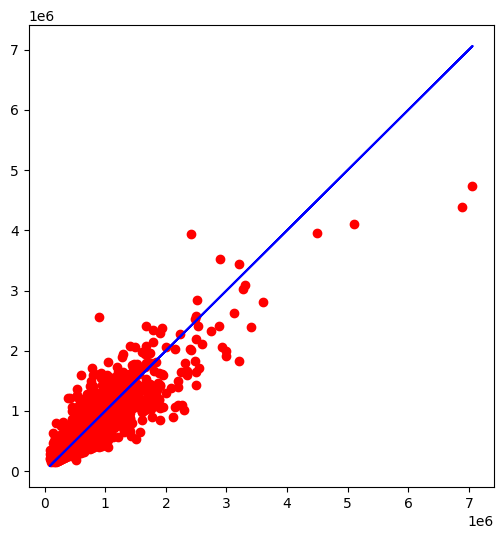

In [55]:
# Plotting Test Data vs Predictions:
plt.figure(figsize= (6,6))
plt.plot(y_test, y_test, c= "b")
plt.scatter(y_test, tf.squeeze(model1_preds), c= "r")
plt.show()

# Creating Model 2 on Houses Pricing Less than 2M:

In [56]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15,month,year
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,47.5112,-122.257,1340,5650,10,2014
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,47.7210,-122.319,1690,7639,12,2014
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,47.7379,-122.233,2720,8062,2,2015
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,47.5208,-122.393,1360,5000,12,2014
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,47.6168,-122.045,1800,7503,2,2015


In [58]:
df.shape

(21597, 20)

In [59]:
df2m = df[df["price"] <= 2000000]

In [60]:
df2m.shape

(21399, 20)

## Train Test Split and Scalling:

In [63]:
x = df2m.drop("price", axis= 1)
y = df2m["price"]

In [64]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.25, random_state= 42)

In [65]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((16049, 19), (5350, 19), (16049,), (5350,))

In [66]:
# Scalling The Data:
sc2 = StandardScaler()
x_train = sc2.fit_transform(x_train)
x_test = sc2.transform(x_test)

## Creating Data Pipelines:

In [67]:
train_features = tf.data.Dataset.from_tensor_slices(x_train)
train_labels = tf.data.Dataset.from_tensor_slices(y_train)
train_dataset = tf.data.Dataset.zip((train_features, train_labels))

train_dataset = train_dataset.batch(128).prefetch(tf.data.AUTOTUNE)

In [68]:
test_features = tf.data.Dataset.from_tensor_slices(x_test)
test_labels = tf.data.Dataset.from_tensor_slices(y_test)
test_dataset = tf.data.Dataset.zip((test_features, test_labels))

test_dataset = test_dataset.batch(128).prefetch(tf.data.AUTOTUNE)

## Creating, Compiling and Fitting The Model:

In [69]:
# Creating The Model:
model2 = Sequential()
model2.add(Dense(32, activation= "relu"))
model2.add(Dense(16, activation= "relu"))
model2.add(Dense(8, activation= "relu"))
model2.add(Dense(1))

# Compiling The Model:
model2.compile(optimizer= Adam(),
               loss= mse,
               metrics= ["mse"])

# Fitting The Model:
model2.fit(train_dataset,
           epochs= 1000,
           validation_data= test_dataset,
           callbacks= [EarlyStopping(monitor= "val_loss",
                                     patience= 5),
                       ModelCheckpoint(filepath= "/content/Model2",
                                       monitor= "val_loss",
                                       save_best_only= True),
                       ReduceLROnPlateau(monitor= "val_loss",
                                         factor= 0.1,
                                         patience= 5,)])

Epoch 1/1000
126/126 [==============================] - 2s 10ms/step - loss: 349819994112.0000 - mse: 349819994112.0000 - val_loss: 362175791104.0000 - val_mse: 362175791104.0000 - lr: 0.0010
Epoch 2/1000
126/126 [==============================] - 1s 9ms/step - loss: 349507223552.0000 - mse: 349507223552.0000 - val_loss: 361310519296.0000 - val_mse: 361310519296.0000 - lr: 0.0010
Epoch 3/1000
126/126 [==============================] - 2s 13ms/step - loss: 347457519616.0000 - mse: 347457519616.0000 - val_loss: 357228347392.0000 - val_mse: 357228347392.0000 - lr: 0.0010
Epoch 4/1000
126/126 [==============================] - 2s 12ms/step - loss: 340695187456.0000 - mse: 340695187456.0000 - val_loss: 346101481472.0000 - val_mse: 346101481472.0000 - lr: 0.0010
Epoch 5/1000
126/126 [==============================] - 1s 9ms/step - loss: 325376737280.0000 - mse: 325376737280.0000 - val_loss: 323828940800.0000 - val_mse: 323828940800.0000 - lr: 0.0010
Epoch 6/1000
126/126 [====================

## Loss Curves of Model:

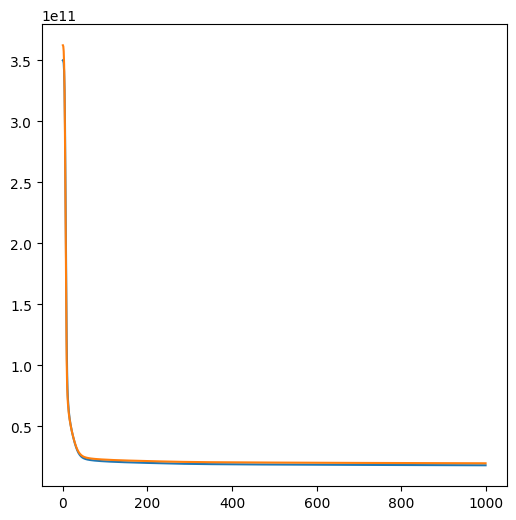

In [70]:
plt.figure(figsize= (6,6))
plt.plot(model2.history.history["loss"])
plt.plot(model2.history.history["val_loss"])
plt.show()

## Model Evaluation:

In [72]:
model2_preds = model2.predict(x_test)

168/168 [==============================] - 1s 3ms/step


In [75]:
# MAE and MSE of Model 2:
mae_2 = tf.metrics.mean_absolute_error(y_test, tf.squeeze(model2_preds))
mse_2 = tf.metrics.mean_squared_error(y_test, tf.squeeze(model2_preds))

mae_2, mse_2

(<tf.Tensor: shape=(), dtype=float32, numpy=93852.78>,
 <tf.Tensor: shape=(), dtype=float32, numpy=19796849000.0>)

In [77]:
r2_score(y_test, tf.squeeze(model2_preds))

0.770486350985496

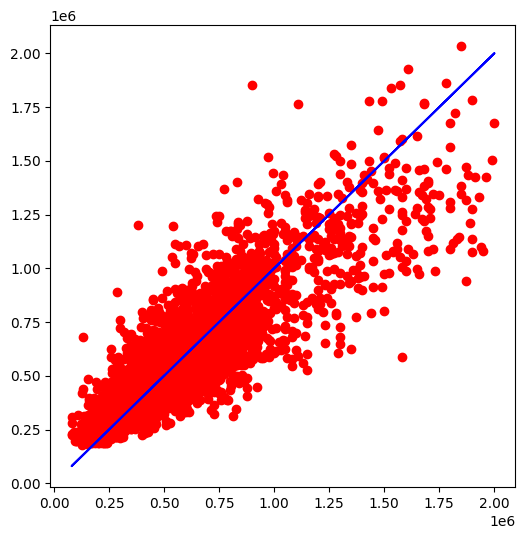

In [79]:
# Plotting Test Data vs Predictions:
plt.figure(figsize= (6,6))
plt.plot(y_test, y_test, c= "b")
plt.scatter(y_test, tf.squeeze(model2_preds), c= "r")
plt.show()